# Promoter Generation & AlphaGenome Evaluation

1. **Part 1-3**: Gene 이름 입력 → TSS upstream 서열 가져오기 → Iterative MLM으로 promoter 생성 → CSV 저장
2. **Part 4**: 저장된 CSV 로드 → AlphaGenome `predict_variants`로 활성 비교 (특정 ontology terms)
3. **Part 5**: 전체 ontology term scan → 어느 cell type에서 가장 높은 활성을 보이는지 확인

In [1]:
# %%capture
# Colab setup
# !git clone https://github.com/leemnj/iterative-dna-reconstruction.git
# %cd iterative-dna-reconstruction/03_dna-fm-to-alphagenome/regulator-to-alphagenome
%pip -q install biopython alphagenome python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [2]:
import gc
import sys
from pathlib import Path

import pandas as pd
import torch

# ── Path setup ───────────────────────────────────────────────────
# utils.py (03_dna-fm-to-alphagenome/)
sys.path.append(str(Path('..').resolve()))
# idr package (01_generate-seq-and-emb/src/)
sys.path.append(str((Path('../..') / '01_generate-seq-and-emb' / 'src').resolve()))

# ── Gene & Promoter Settings ─────────────────────────────────────
GENE_NAME = 'GAPDH'
PROMOTER_TSS_LENGTH = 300        # -250 ~ +50 bp from TSS

# ── Iterative MLM Settings ───────────────────────────────────────
ITERATIONS = 20
MASK_RATIO = 0.1
DECODING_STRATEGY = 'sampling'   # 'greedy', 'sampling', 'top_k'
TEMPERATURE = 1.0
TOP_K = 50
TORCH_DTYPE = 'float32'

MODEL_CONFIGS = {
    'DNABERT-2': 'zhihan1996/DNABERT-2-117M',
    'NT-v2-50m': 'InstaDeepAI/nucleotide-transformer-v2-50m-multi-species',
    'NT-v2-500m': 'InstaDeepAI/nucleotide-transformer-v2-500m-multi-species',
    'NT-v3-650m-pre': 'InstaDeepAI/NTv3_650M_pre',
    'NT-v3-650m-post': 'InstaDeepAI/NTv3_650M_post',
}

# ── AlphaGenome Evaluation Settings ──────────────────────────────
REQUESTED_OUTPUT_TYPES = {'CAGE', 'PROCAP', 'RNA_SEQ'}  # 수정 가능
ONTOLOGY_TERMS = ['EFO:0002067', 'CL:0000765']          # None = 모든 ontology
EVAL_ITERATIONS = [0, 5, 10, 15, 20]                     # 평가할 iteration 목록

# ── Data Paths ───────────────────────────────────────────────────
DATA_DIR = Path('../../data')
PROMOTER_DIR = (
    DATA_DIR / 'promoters'
    / f'{DECODING_STRATEGY}_t{TEMPERATURE}_mask{MASK_RATIO}_iter{ITERATIONS}'
)
PROMOTER_DIR.mkdir(parents=True, exist_ok=True)

ENSEMBL_SPECIES = 'human'
ENSEMBL_ASSEMBLY = 'GRCh38'

MODEL_LABELS = list(MODEL_CONFIGS.keys())

print(f'Gene: {GENE_NAME}')
print(f'Promoter length: {PROMOTER_TSS_LENGTH} bp')
print(f'Strategy: {DECODING_STRATEGY}, T={TEMPERATURE}, top_k={TOP_K}')
print(f'Iterations: {ITERATIONS}, Mask ratio: {MASK_RATIO}')
print(f'Models: {MODEL_LABELS}')
print(f'Output dir: {PROMOTER_DIR}')

Gene: GAPDH
Promoter length: 300 bp
Strategy: sampling, T=1.0, top_k=50
Iterations: 20, Mask ratio: 0.1
Models: ['DNABERT-2', 'NT-v2-50m', 'NT-v2-500m', 'NT-v3-650m-pre', 'NT-v3-650m-post']
Output dir: ../../data/promoters/sampling_t1.0_mask0.1_iter20


## Part 2: Gene Lookup & Sequence Fetch

In [3]:
from utils import (
    load_gtf_feather,
    get_sequence_from_ensembl_region,
    normalize_sequence,
)

gtf = load_gtf_feather(data_dir=DATA_DIR)

# Find gene in GTF
gene_gtf = gtf[
    (gtf['gene_name'] == GENE_NAME) & (gtf['transcript_support_level'] == '1')
].iloc[0]

chrom = gene_gtf['Chromosome']
strand = gene_gtf['Strand']
gene_start = int(gene_gtf['Start'])
gene_end = int(gene_gtf['End'])
gene_id = gene_gtf['gene_id']

print(f'{GENE_NAME} ({gene_id}): {chrom}:{gene_start}-{gene_end} ({strand})')

gencode.v46.annotation.gtf.gz.feather already exists!
GAPDH (ENSG00000111640.15): chr12:6534516-6538371 (+)


In [4]:
# Calculate TSS and promoter region
if strand == '+':
    tss = gene_start + 50
    promoter_start = tss - PROMOTER_TSS_LENGTH
    promoter_end = tss
else:
    tss = gene_end - 50
    promoter_start = tss
    promoter_end = tss + PROMOTER_TSS_LENGTH

print(f'TSS: {chrom}:{tss} ({strand})')
print(f'Promoter region (hg38): {chrom}:{promoter_start}-{promoter_end}')

# Fetch from Ensembl
promoter_seq_raw = get_sequence_from_ensembl_region(
    ENSEMBL_SPECIES, chrom, promoter_start, promoter_end,
    strand, coord_system_version=ENSEMBL_ASSEMBLY,
)
promoter_seq = normalize_sequence(promoter_seq_raw)

print(f'Promoter sequence length: {len(promoter_seq)}')
print(f'{promoter_seq[:50]}...{promoter_seq[-50:]}')

TSS: chr12:6534566 (+)
Promoter region (hg38): chr12:6534266-6534566
Promoter sequence length: 300
CAATCTCAGTCCCTTCCCCCCTACGTCGGGGCCCACACGCTCGGTGCGTG...CGCTCTCTGCTCCTCCTGTTCGACAGTCAGCCGCATCTTCTTTTGCGTCG


## Part 3: Iterative MLM Sequence Generation
각 모델로 iterative masked language modeling을 수행하여 promoter 서열을 생성합니다.

In [5]:
from idr.utils import get_device, iter_models

device = get_device()
print(f'Device: {device}')

for model_label, model_instance in iter_models(
    device, MODEL_CONFIGS, torch_dtype=TORCH_DTYPE
):
    print(f'\n=== {model_label} ===')

    model_dir = PROMOTER_DIR / model_label
    model_dir.mkdir(parents=True, exist_ok=True)
    output_csv = model_dir / f'{GENE_NAME}_promoter.csv'

    # Run iterative MLM
    generated_sequences = model_instance.run(
        sequence=promoter_seq,
        steps=ITERATIONS,
        mask_ratio=MASK_RATIO,
        strategy=DECODING_STRATEGY,
        temperature=TEMPERATURE,
        top_k=TOP_K,
        save_all=True,
        save_interval=1,
    )

    strategy_key = (
        DECODING_STRATEGY if DECODING_STRATEGY == 'greedy'
        else f'{DECODING_STRATEGY}_t{TEMPERATURE}'
    )
    results_data = {strategy_key: generated_sequences}

    df = pd.DataFrame(results_data).T
    df.columns = [f'iter_{i:02d}' for i in range(df.shape[1])]
    df.to_csv(output_csv)
    print(f'Saved: {output_csv}')

    # Length check (DNABERT-2 may produce shorter sequences)
    final_len = len(generated_sequences[-1])
    if final_len != len(promoter_seq):
        print(f'  ⚠️ Length changed: {len(promoter_seq)} → {final_len}')

    del generated_sequences, model_instance
    gc.collect()
    if device == 'cuda':
        torch.cuda.empty_cache()
    elif device == 'mps':
        torch.mps.empty_cache()

print('\n=== All models done ===')

PyTorch Version: 2.9.1
Using device: mps
Device: mps
📥 Downloading DNABERT-2...


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

✅ DNABERT-2 Triton patch applied successfully.
[DNABERT-2] Loading model...


/Users/leeminjae/.cache/huggingface/modules/transformers_modules/_7bce263b15377fc15361f52cfab88f8b586abda0/bert_layers.py:126: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


[DNABERT-2] Model loaded successfully.
✅ DNABERT-2 loaded successfully.

=== DNABERT-2 ===
Saved: ../../data/promoters/sampling_t1.0_mask0.1_iter20/DNABERT-2/GAPDH_promoter.csv
  ⚠️ Length changed: 300 → 292
[NT-v2-50m] Loading model...
[NT-v2-50m] Model loaded successfully.
✅ NT-v2-50m loaded successfully.

=== NT-v2-50m ===
Saved: ../../data/promoters/sampling_t1.0_mask0.1_iter20/NT-v2-50m/GAPDH_promoter.csv
[NT-v2-500m] Loading model...
[NT-v2-500m] Model loaded successfully.
✅ NT-v2-500m loaded successfully.

=== NT-v2-500m ===
Saved: ../../data/promoters/sampling_t1.0_mask0.1_iter20/NT-v2-500m/GAPDH_promoter.csv
[NT-v3-650m-pre] Loading model...
[NT-v3-650m-pre] Model loaded successfully.
✅ NT-v3-650m-pre loaded successfully.

=== NT-v3-650m-pre ===
Saved: ../../data/promoters/sampling_t1.0_mask0.1_iter20/NT-v3-650m-pre/GAPDH_promoter.csv
[NT-v3-650m-post] Loading model...
[NT-v3-650m-post] AutoModelForMaskedLM load failed, using AutoModel fallback: Unrecognized configuration clas

---
## Part 4: AlphaGenome Evaluation — Specific Ontology Terms
저장된 CSV를 로드하여 AlphaGenome으로 활성 변화를 평가합니다.

**이 섹션부터는 Part 3과 독립적으로 실행 가능합니다** (CSV만 있으면 됨).

In [6]:
import copy

from utils import (
    get_dna_model,
    get_output_metadata,
    load_gtf_feather,
    prepare_gtf_views,
    build_transcript_extractors,
    get_sequence_from_ensembl_region,
    normalize_sequence,
    reverse_complement,
)

# ── Load generated promoter CSVs ─────────────────────────────────
promoter_dfs = {}
for model in MODEL_LABELS:
    csv_path = PROMOTER_DIR / model / f'{GENE_NAME}_promoter.csv'
    df = pd.read_csv(csv_path, index_col=0)
    promoter_dfs[model] = df
    print(f'[{model}] shape={df.shape}, strategies={list(df.index)}')

# Determine the strategy key used during generation
strategy_key = (
    DECODING_STRATEGY if DECODING_STRATEGY == 'greedy'
    else f'{DECODING_STRATEGY}_t{TEMPERATURE}'
)

# Extract sequences for evaluation iterations
seqs_by_model = {}
for model, df in promoter_dfs.items():
    seqs = {
        f'iter_{i:02d}': df.loc[strategy_key, f'iter_{i:02d}']
        for i in EVAL_ITERATIONS
    }
    seqs_by_model[model] = seqs
    lengths = ' '.join(f'iter_{i:02d}={len(seqs[f"iter_{i:02d}"])}' for i in EVAL_ITERATIONS)
    print(f'[{model}] {lengths}')

[DNABERT-2] shape=(1, 21), strategies=['sampling_t1.0']
[NT-v2-50m] shape=(1, 21), strategies=['sampling_t1.0']
[NT-v2-500m] shape=(1, 21), strategies=['sampling_t1.0']
[NT-v3-650m-pre] shape=(1, 21), strategies=['sampling_t1.0']
[NT-v3-650m-post] shape=(1, 21), strategies=['sampling_t1.0']
[DNABERT-2] iter_00=300 iter_05=292 iter_10=277 iter_15=287 iter_20=292
[NT-v2-50m] iter_00=300 iter_05=300 iter_10=300 iter_15=300 iter_20=300
[NT-v2-500m] iter_00=300 iter_05=300 iter_10=300 iter_15=300 iter_20=300
[NT-v3-650m-pre] iter_00=300 iter_05=300 iter_10=300 iter_15=300 iter_20=300
[NT-v3-650m-post] iter_00=300 iter_05=300 iter_10=300 iter_15=300 iter_20=300


In [7]:
from alphagenome.data import genome
from alphagenome.models import dna_client

# ── AlphaGenome client ───────────────────────────────────────────
dna_model = get_dna_model()
output_metadata = get_output_metadata(dna_model)

# ── GTF & transcript extractors ──────────────────────────────────
gtf = load_gtf_feather(data_dir=DATA_DIR)
gtf_transcript, gtf_longest_transcript = prepare_gtf_views(gtf)
transcript_extractor, longest_transcript_extractor = (
    build_transcript_extractors(gtf_transcript, gtf_longest_transcript)
)

# ── Resolve output types ─────────────────────────────────────────
requested_outputs = {
    getattr(dna_client.OutputType, ot) for ot in REQUESTED_OUTPUT_TYPES
}
print(f'Output types: {REQUESTED_OUTPUT_TYPES}')
print(f'Ontology terms: {ONTOLOGY_TERMS}')

gencode.v46.annotation.gtf.gz.feather already exists!
Output types: {'CAGE', 'RNA_SEQ', 'PROCAP'}
Ontology terms: ['EFO:0002067', 'CL:0000765']


In [8]:
# ── Prepare sequences (handle strand orientation) ────────────────
PROMO_LENGTH = len(seqs_by_model[MODEL_LABELS[0]][f'iter_{EVAL_ITERATIONS[0]:02d}'])

oriented_seqs_by_model = copy.deepcopy(seqs_by_model)

if strand == '-':
    seq_original = normalize_sequence(get_sequence_from_ensembl_region(
        ENSEMBL_SPECIES, chrom, tss, tss + PROMO_LENGTH,
        strand, coord_system_version=ENSEMBL_ASSEMBLY,
    ))
    seq_original = reverse_complement(seq_original)
    for model, iters in oriented_seqs_by_model.items():
        for it, seq in iters.items():
            iters[it] = reverse_complement(seq)
else:
    seq_original = normalize_sequence(get_sequence_from_ensembl_region(
        ENSEMBL_SPECIES, chrom, tss - PROMO_LENGTH, tss,
        strand, coord_system_version=ENSEMBL_ASSEMBLY,
    ))

print(f'Original promoter: {len(seq_original)} bp')

# ── Predict variants ─────────────────────────────────────────────
interval = genome.Interval(chrom, gene_start, gene_end).resize(2**20)
variant_position = gene_start - PROMO_LENGTH if strand == '+' else tss

outputs_by_model = {}
for model in MODEL_LABELS:
    print(f'Predicting: {model}...')
    variants = [
        genome.Variant(
            chrom, variant_position,
            seq_original,
            oriented_seqs_by_model[model][f'iter_{i:02d}'],
        )
        for i in EVAL_ITERATIONS
    ]

    outputs = dna_model.predict_variants(
        intervals=interval,
        variants=variants,
        requested_outputs=requested_outputs,
        ontology_terms=ONTOLOGY_TERMS,
        progress_bar=True,
    )
    outputs_by_model[model] = outputs

print('All predictions done.')

Original promoter: 300 bp
Predicting: DNABERT-2...


  0%|          | 0/5 [00:00<?, ?it/s]

Predicting: NT-v2-50m...


  0%|          | 0/5 [00:00<?, ?it/s]

Predicting: NT-v2-500m...


...

Predicting: NT-v3-650m-pre...


  0%|          | 0/5 [00:00<?, ?it/s]

Predicting: NT-v3-650m-post...


  0%|          | 0/5 [00:00<?, ?it/s]

All predictions done.


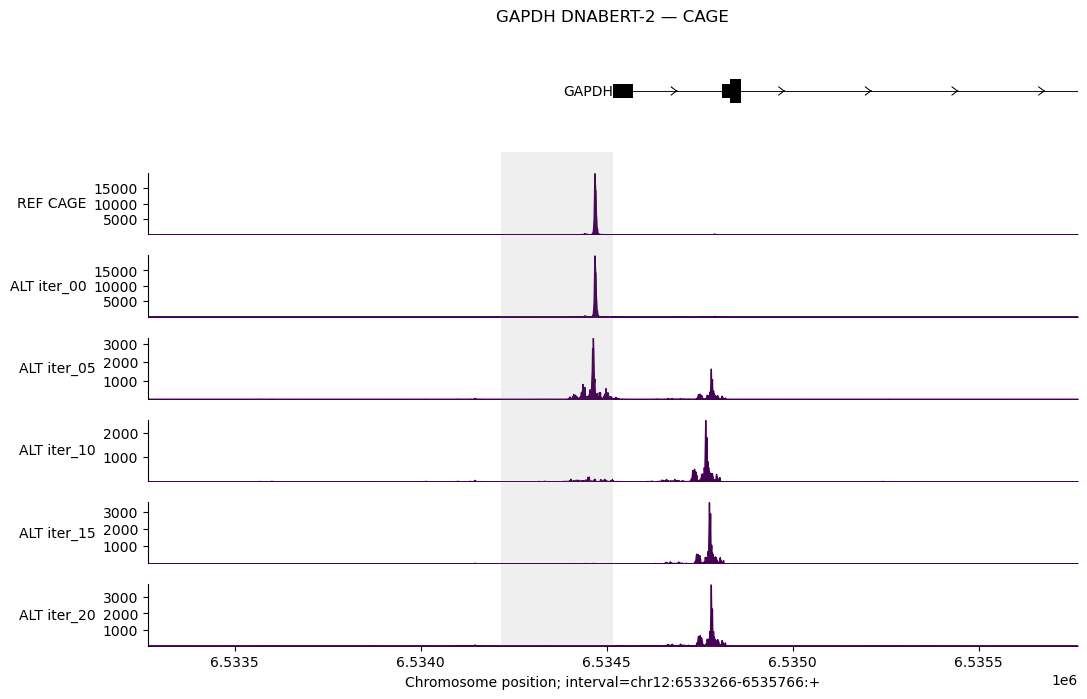

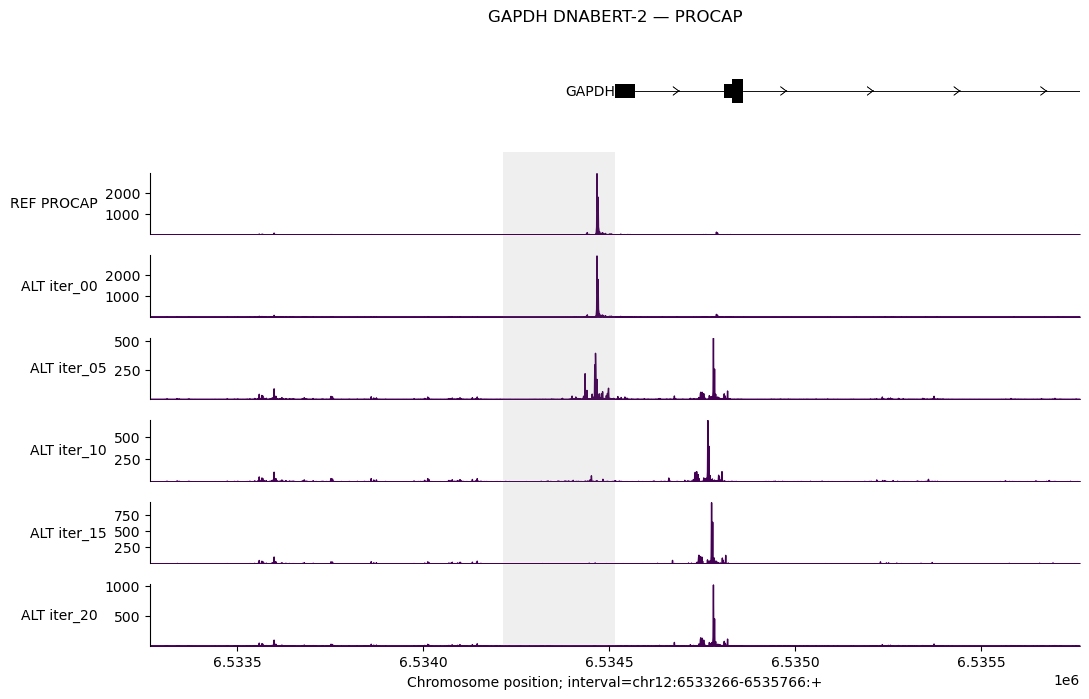

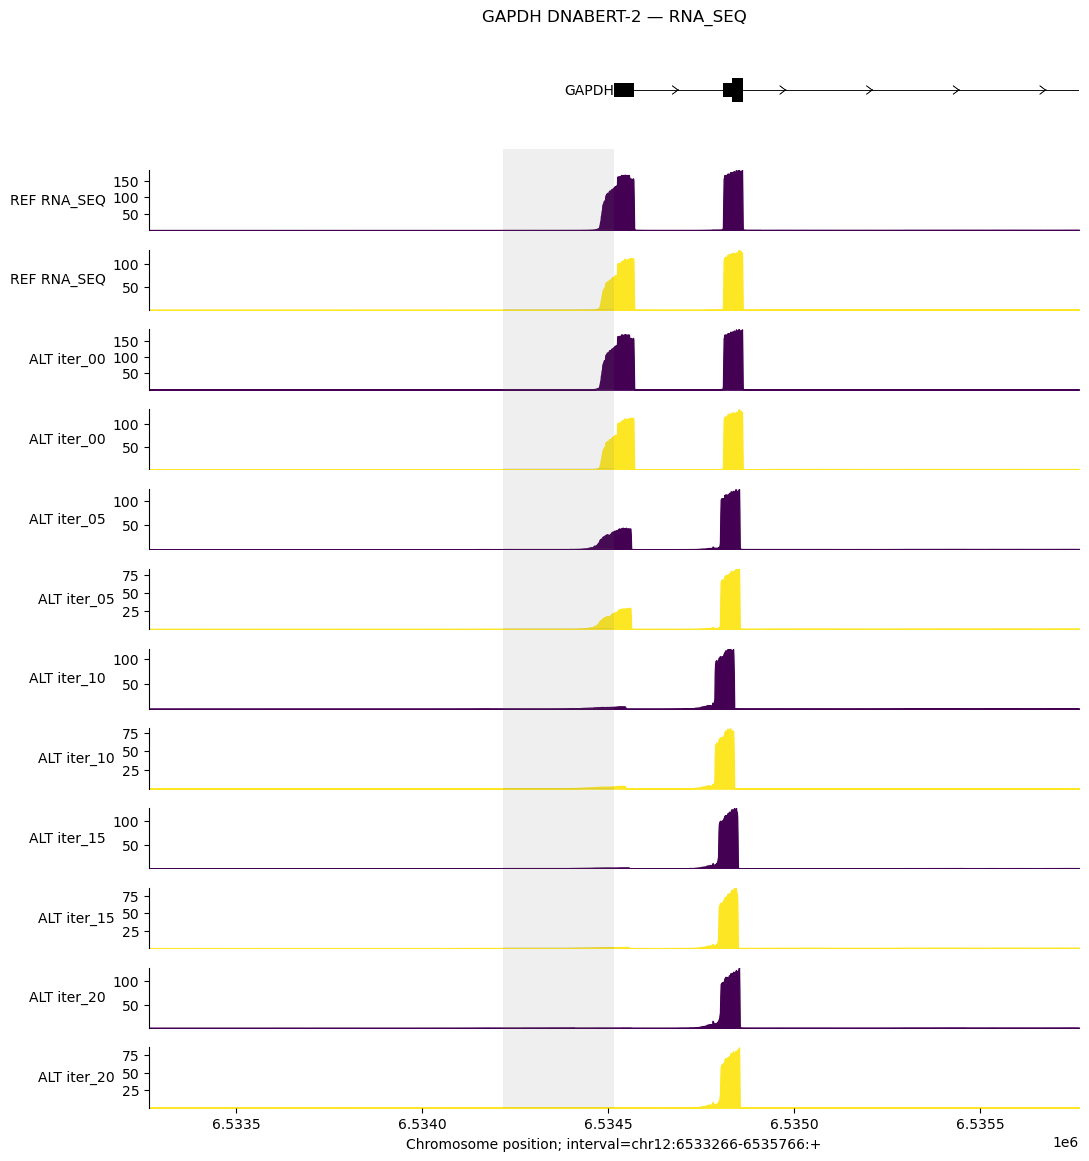

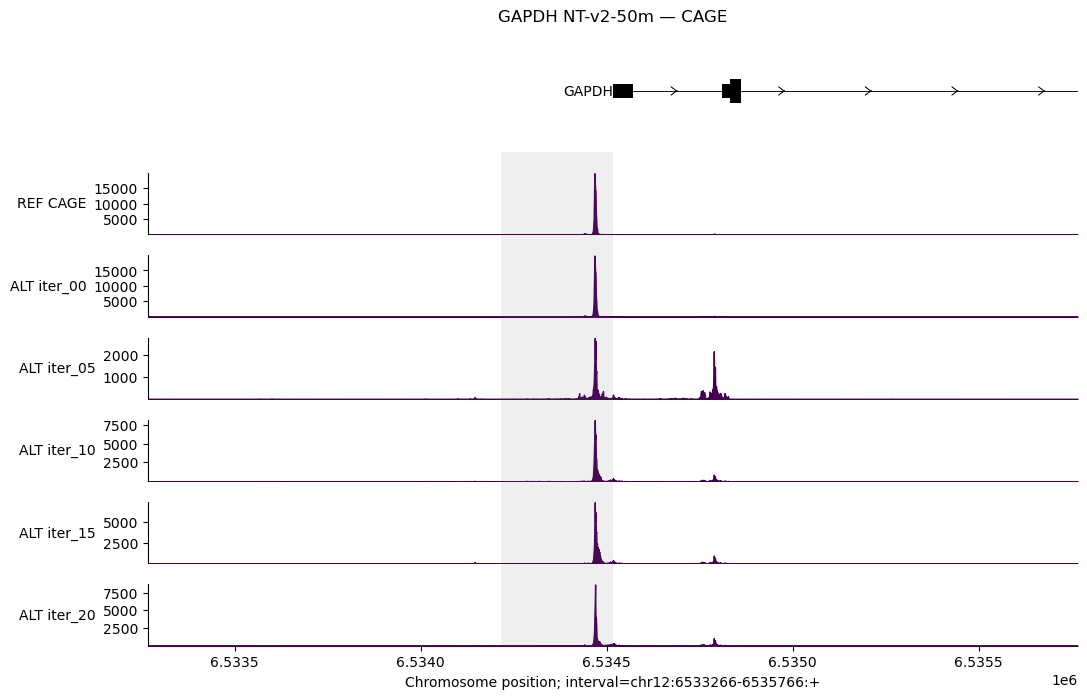

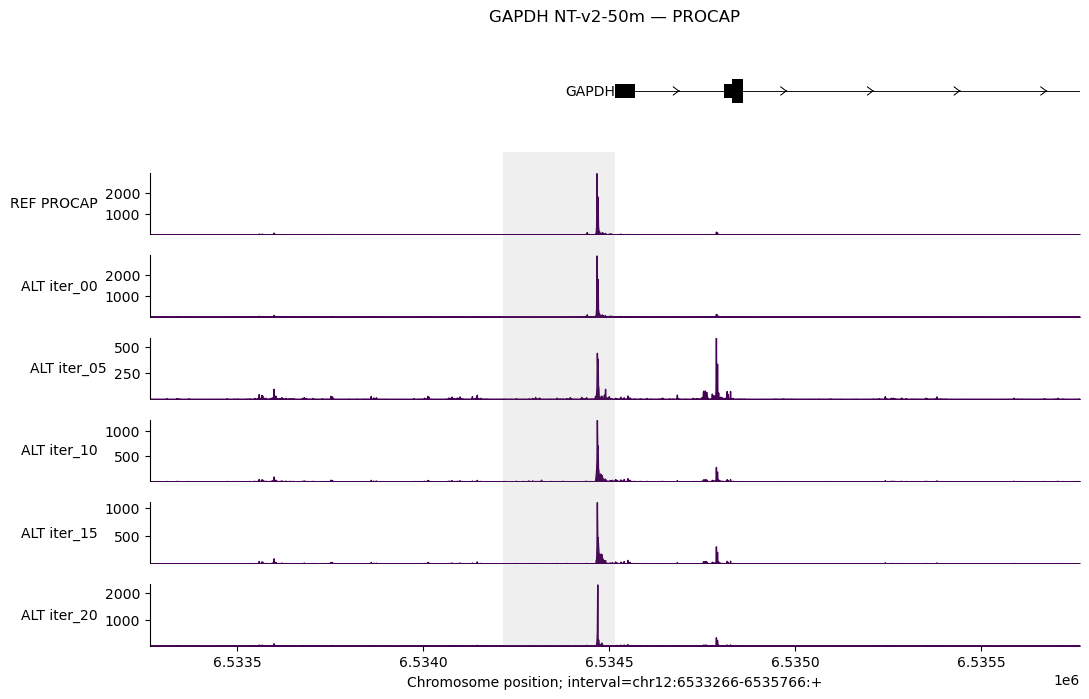

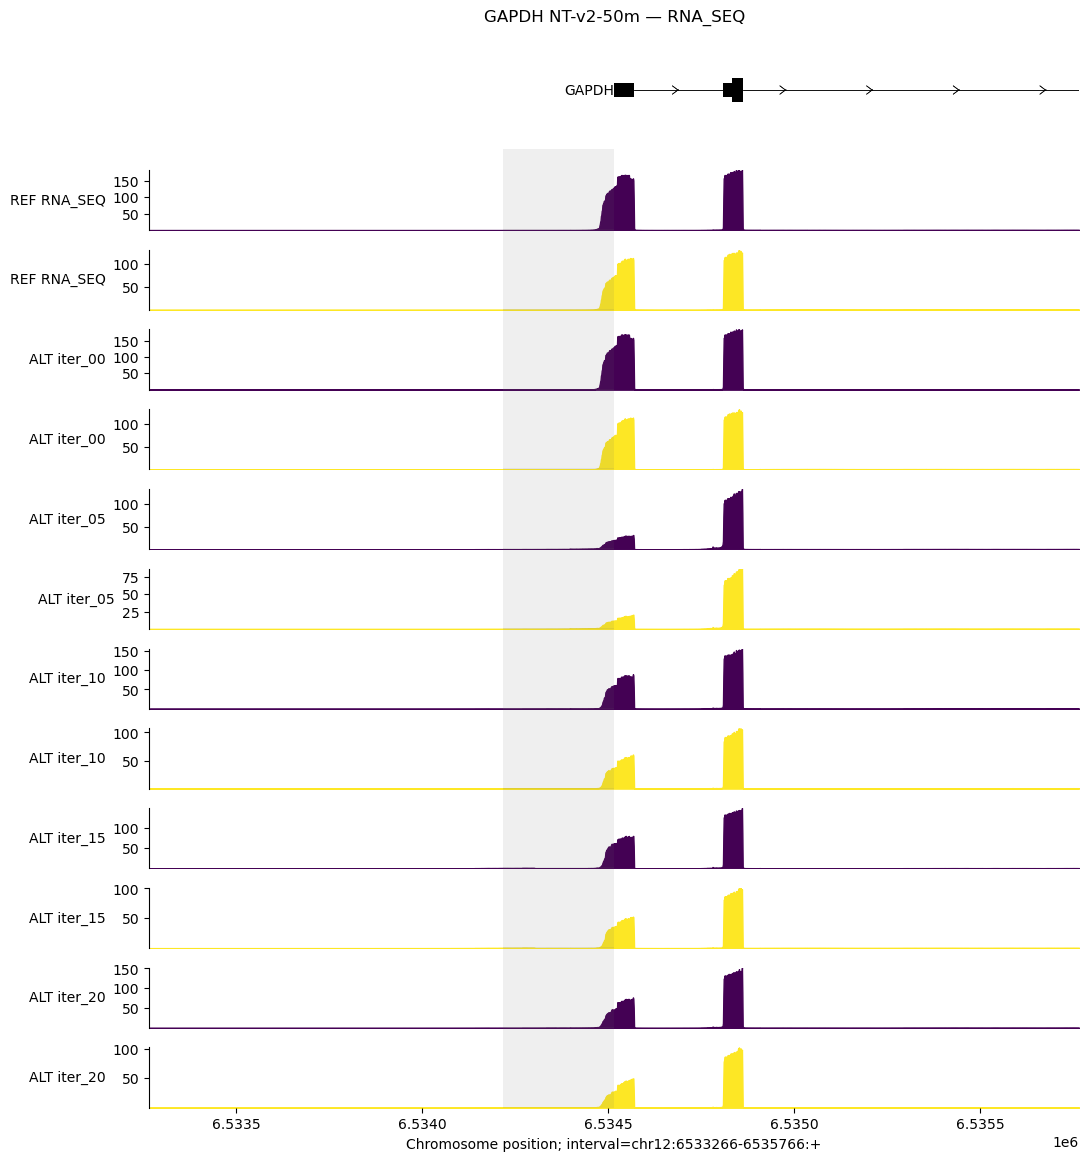

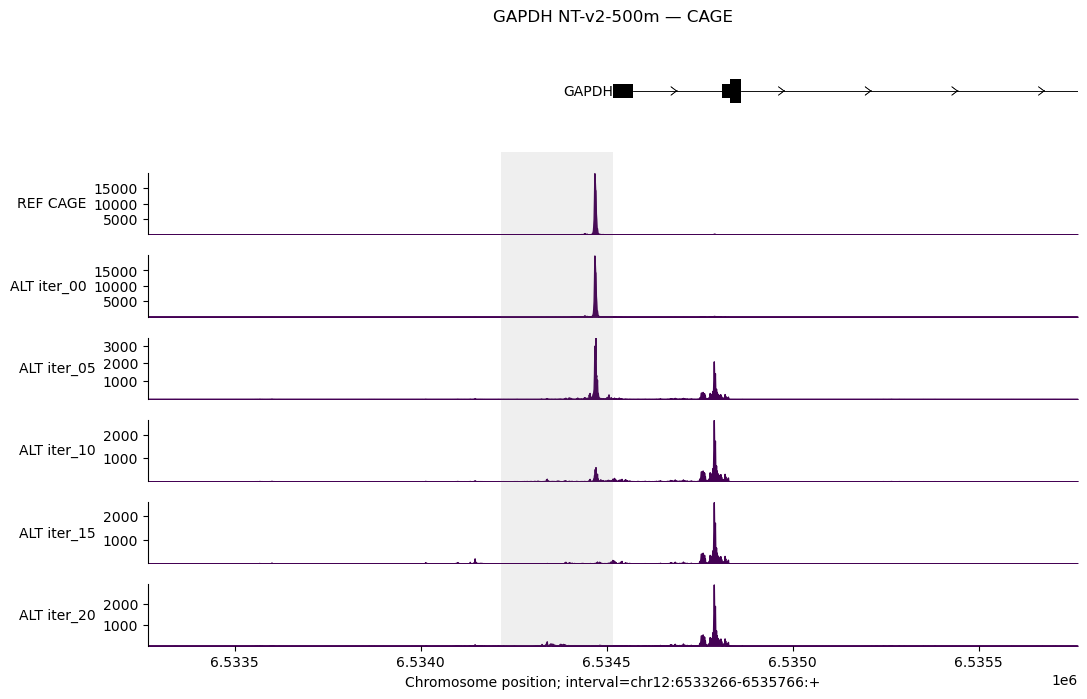

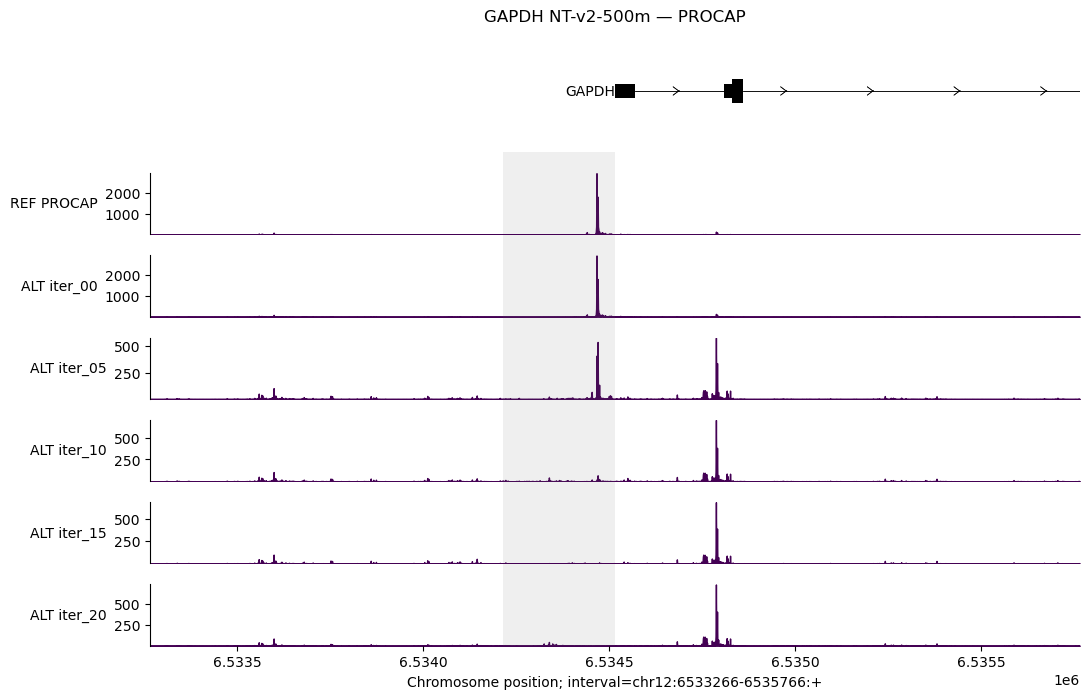

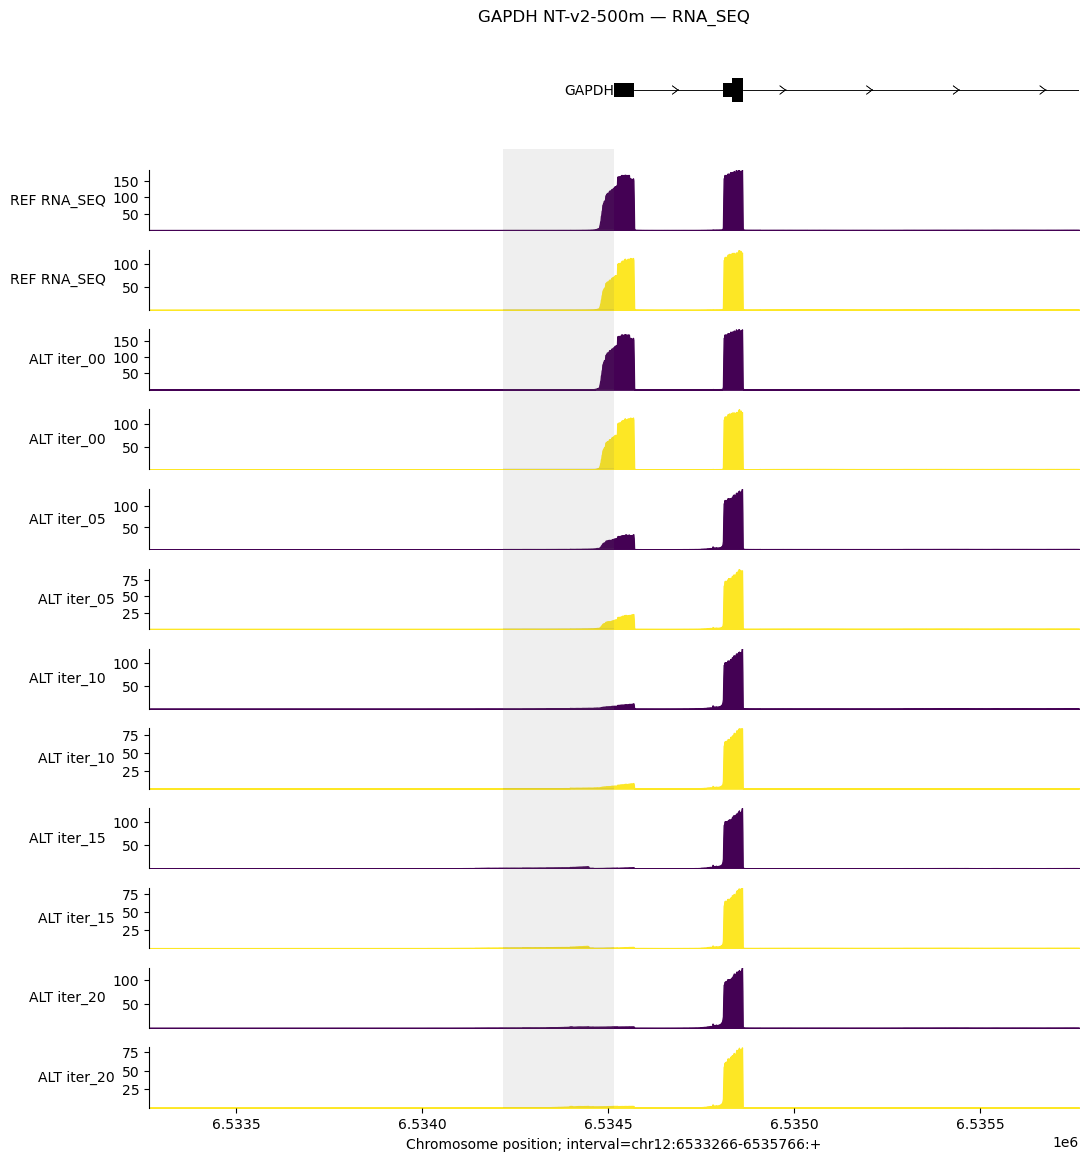

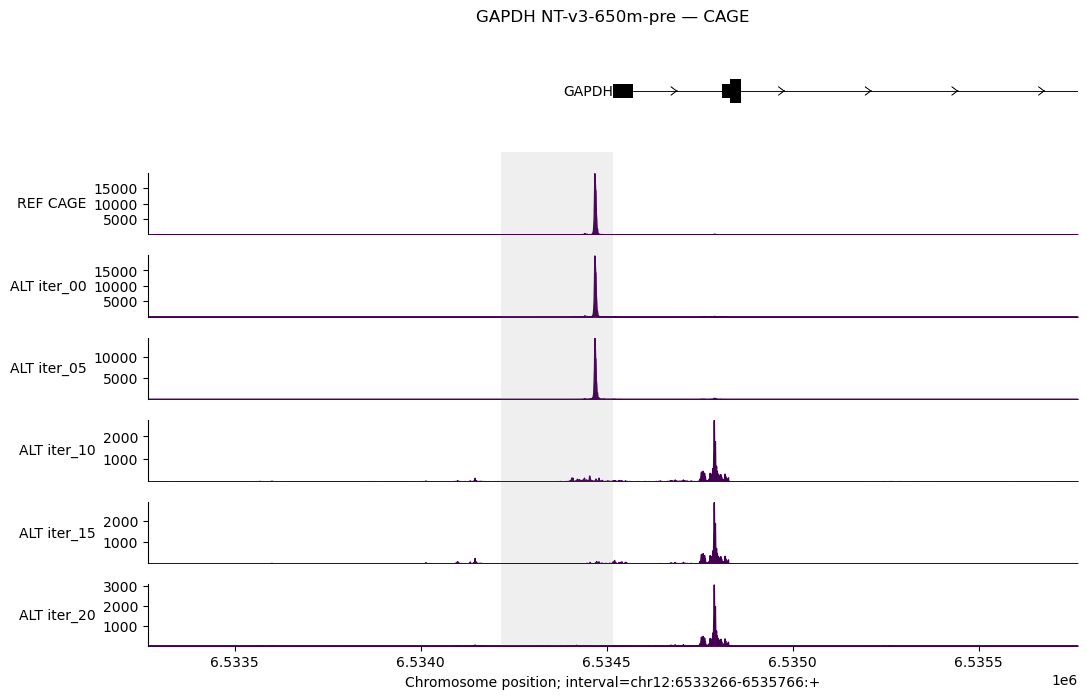

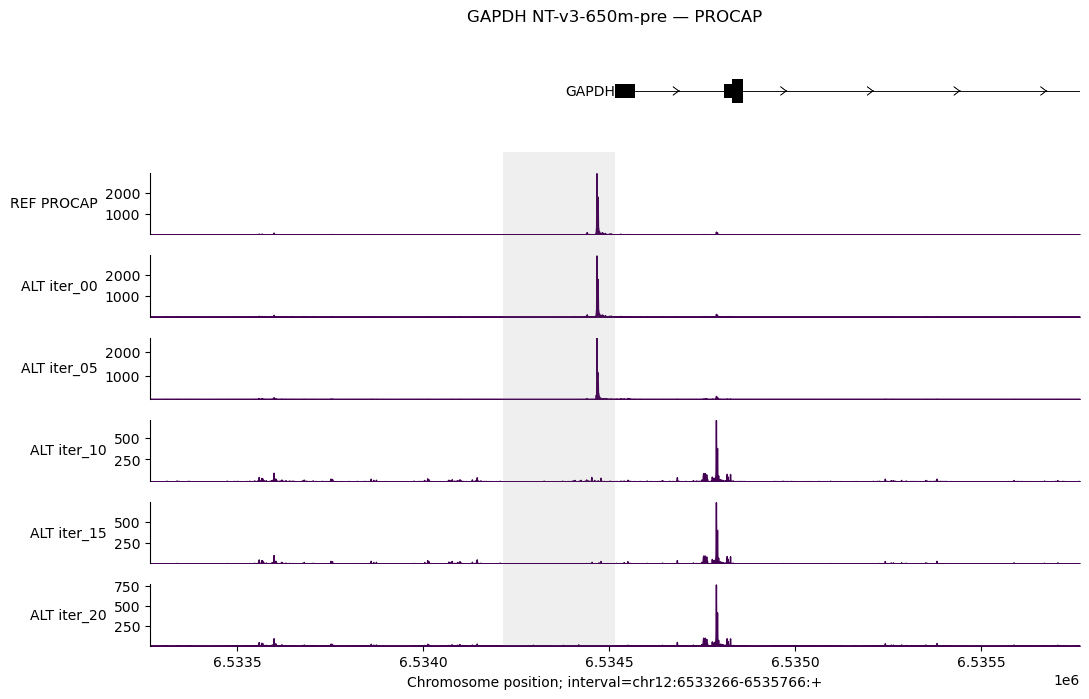

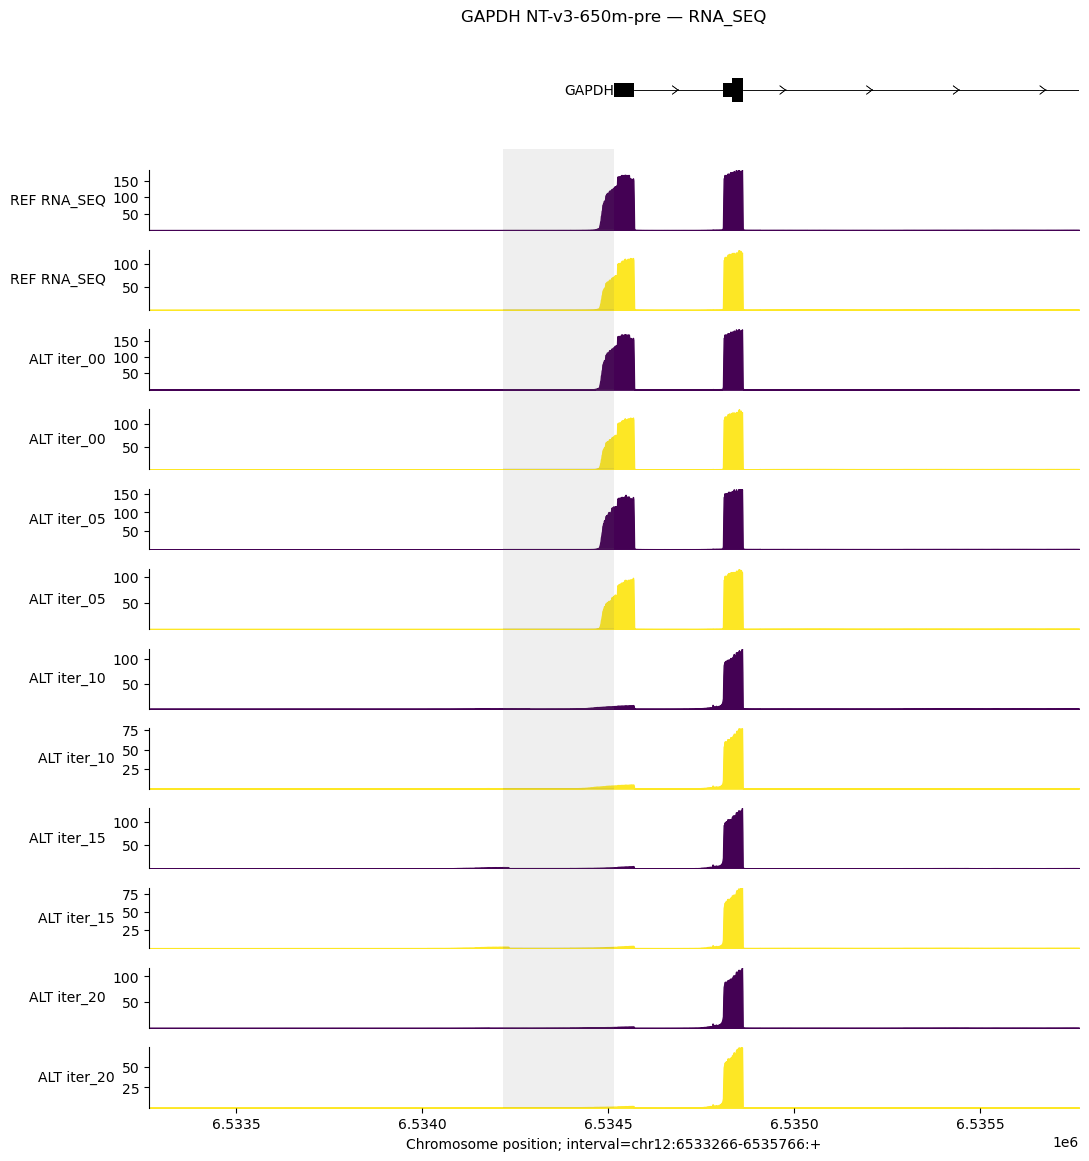

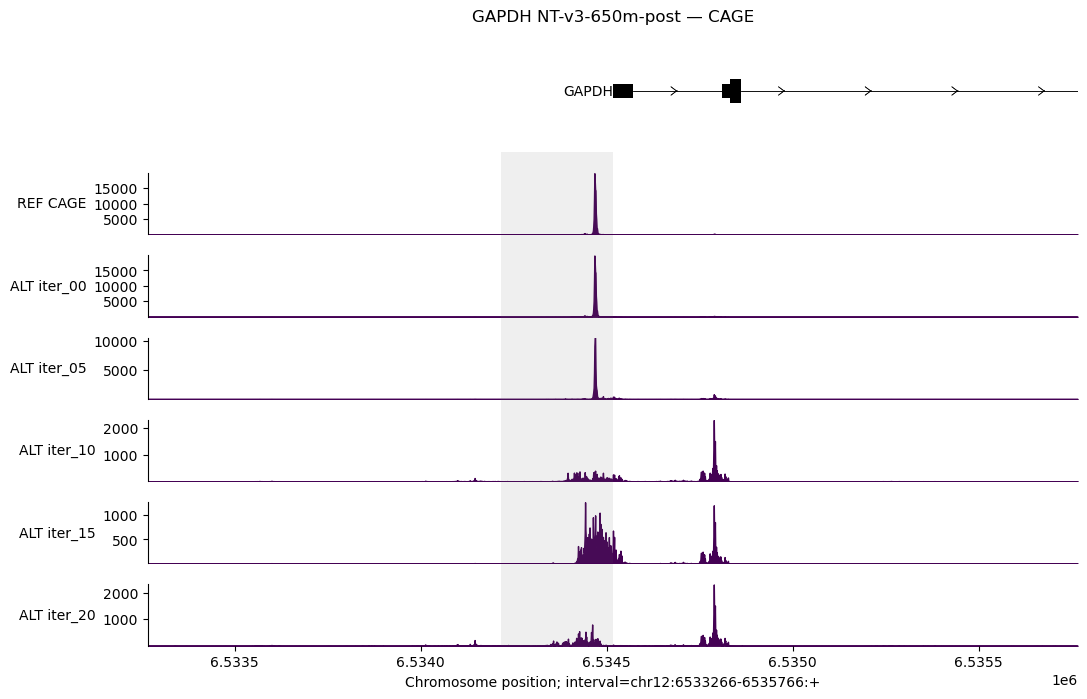

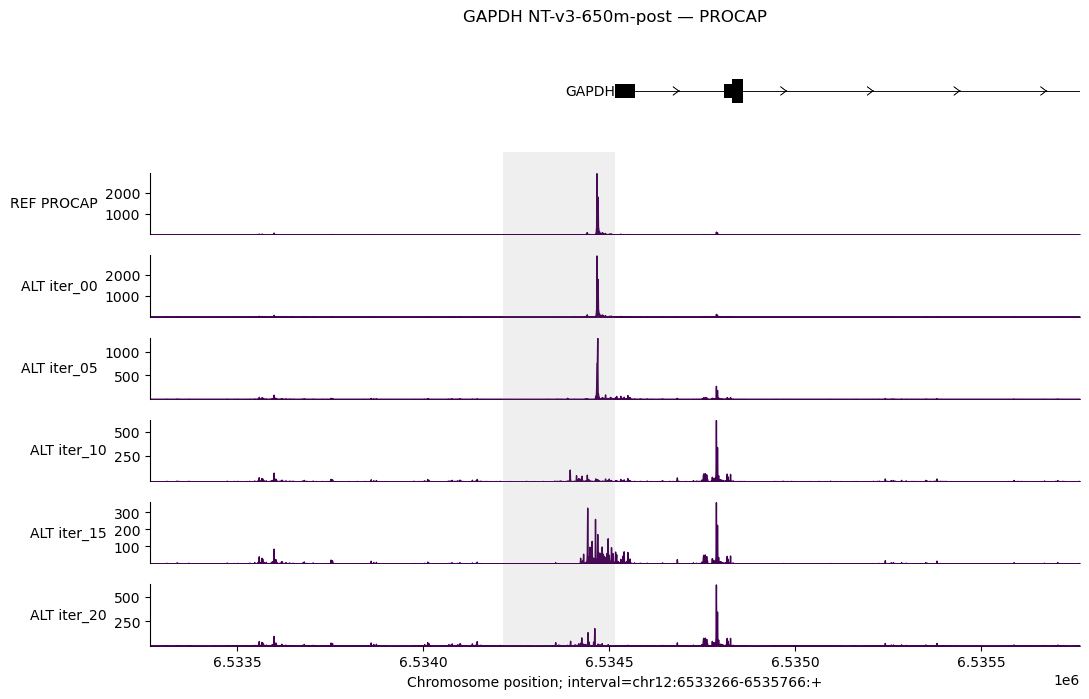

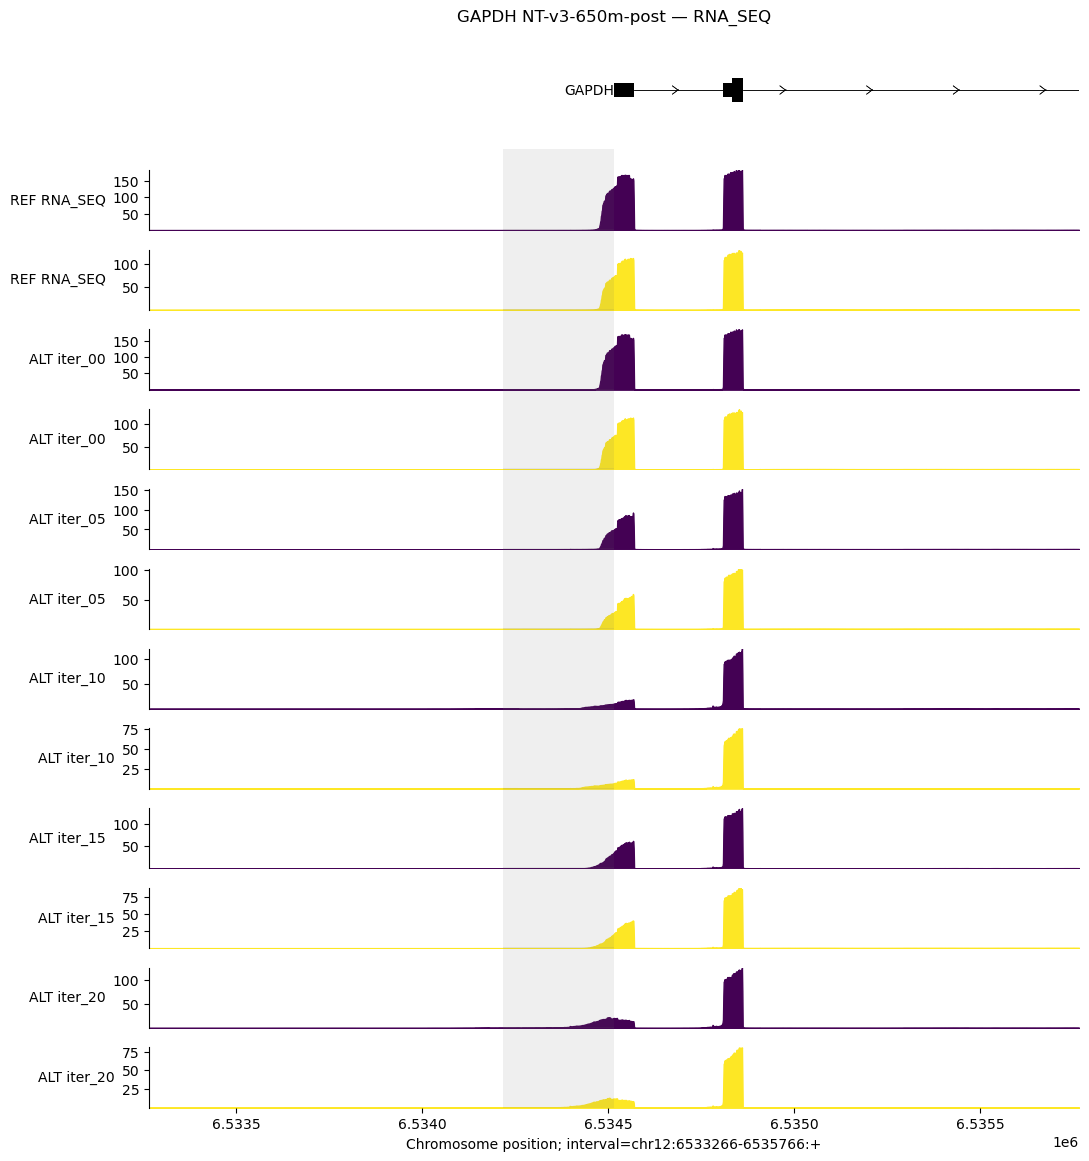

In [9]:
from alphagenome.visualization import plot_components as pc

interval_vis = genome.Interval(chrom, gene_start - 500, gene_start + 500, strand='+')
longest_transcripts = longest_transcript_extractor.extract(interval)
promoter_interval = [
    genome.Interval(chrom, variant_position, variant_position + PROMO_LENGTH, name='Promoter')
]

OUTPUT_ATTRS = {
    'CAGE': 'cage',
    'PROCAP': 'procap',
    'RNA_SEQ': 'rna_seq',
}
# Filter to only requested output types
active_attrs = {k: v for k, v in OUTPUT_ATTRS.items() if k in REQUESTED_OUTPUT_TYPES}

for model in MODEL_LABELS:
    outputs = outputs_by_model[model]
    for label, attr in active_attrs.items():
        ref_track = getattr(outputs[0].reference, attr).filter_to_positive_strand()
        alt_tracks = [
            getattr(o.alternate, attr).filter_to_positive_strand()
            for o in outputs
        ]

        components = [
            pc.TranscriptAnnotation(longest_transcripts),
            pc.Tracks(ref_track, filled=True, ylabel_template=f'REF {label}'),
        ]
        for i, alt in zip(EVAL_ITERATIONS, alt_tracks):
            components.append(
                pc.Tracks(alt, filled=True, ylabel_template=f'ALT iter_{i:02d}')
            )

        pc.plot(
            components,
            interval=interval_vis.resize(2500),
            annotations=[
                pc.IntervalAnnotation(promoter_interval, colors='dimgrey', alpha=0.1),
            ],
            title=f'{GENE_NAME} {model} — {label}',
            fig_width=12,
        )

In [10]:
import numpy as np

# ── Quantitative comparison: CAGE peak around TSS ────────────────
summary_rows = []

for model in MODEL_LABELS:
    outputs = outputs_by_model[model]
    ref_cage = outputs[0].reference.cage.filter_to_positive_strand()
    ref_peak = float(np.max(ref_cage.values))
    ref_sum = float(np.sum(ref_cage.values))

    for idx, i in enumerate(EVAL_ITERATIONS):
        alt_cage = outputs[idx].alternate.cage.filter_to_positive_strand()
        alt_peak = float(np.max(alt_cage.values))
        alt_sum = float(np.sum(alt_cage.values))
        summary_rows.append({
            'model': model,
            'iteration': f'iter_{i:02d}',
            'ref_peak': ref_peak,
            'alt_peak': alt_peak,
            'ref_sum': ref_sum,
            'alt_sum': alt_sum,
            'peak_delta': alt_peak - ref_peak,
            'peak_ratio': alt_peak / ref_peak if ref_peak > 0 else float('nan'),
        })

summary_df = pd.DataFrame(summary_rows)
print(f'=== CAGE Signal Summary for {GENE_NAME} ===')
summary_df

=== CAGE Signal Summary for GAPDH ===


,model,iteration,ref_peak,alt_peak,ref_sum,alt_sum,peak_delta,peak_ratio
0,DNABERT-2,iter_00,19840.0,19840.0,244461.21875,244461.218750,0.0,1.000000
1,DNABERT-2,iter_05,19840.0,6528.0,244461.21875,179165.078125,-13312.0,0.329032
2,DNABERT-2,iter_10,19840.0,7232.0,244461.21875,155239.703125,-12608.0,0.364516
3,DNABERT-2,iter_15,19840.0,6848.0,244461.21875,165445.078125,-12992.0,0.345161
4,DNABERT-2,iter_20,19840.0,6464.0,244461.21875,163278.281250,-13376.0,0.325806
5,NT-v2-50m,iter_00,19840.0,19840.0,244461.21875,244461.218750,0.0,1.000000
6,NT-v2-50m,iter_05,19840.0,6592.0,244461.21875,172294.546875,-13248.0,0.332258
7,NT-v2-50m,iter_10,19840.0,8128.0,244461.21875,194030.000000,-11712.0,0.409677
8,NT-v2-50m,iter_15,19840.0,7424.0,244461.21875,198206.578125,-12416.0,0.374194
9,NT-v2-50m,iter_20,19840.0,8640.0,244461.21875,186247.625000,-11200.0,0.435484


---
## Part 5: All Ontology Terms Scan
생성된 서열이 다른 cell type에서 더 높은 활성을 보일 가능성을 확인합니다.

`ontology_terms=None`으로 설정하면 모든 가능한 cell ontology에 대해 예측합니다.

**API 비용 절감을 위해 마지막 iteration, 하나의 모델에 대해서만 수행합니다.**

In [ ]:
# ── Settings for ontology scan ───────────────────────────────────
SCAN_MODELS = MODEL_LABELS                       # 모든 모델 스캔 (수정 가능)
SCAN_ITERATION = 5                               # iteration 5 사용

print(f'Scanning: models={SCAN_MODELS}, iteration=iter_{SCAN_ITERATION:02d}')

In [ ]:
scan_requested = {dna_client.OutputType.CAGE}
scan_outputs_by_model = {}

for scan_model in SCAN_MODELS:
    scan_seq = oriented_seqs_by_model[scan_model][f'iter_{SCAN_ITERATION:02d}']
    scan_variant = genome.Variant(
        chrom, variant_position, seq_original, scan_seq,
    )

    print(f'Predicting {scan_model} with ontology_terms=None (all cell types)...')
    scan_output = dna_model.predict_variant(
        interval=interval,
        variant=scan_variant,
        requested_outputs=scan_requested,
        ontology_terms=None,
    )
    scan_outputs_by_model[scan_model] = scan_output

print('All done.')

In [ ]:
# ── Analyze which cell types show highest CAGE activity ──────────
for scan_model in SCAN_MODELS:
    scan_output = scan_outputs_by_model[scan_model]
    alt_cage = scan_output.alternate.cage.filter_to_positive_strand()
    ref_cage = scan_output.reference.cage.filter_to_positive_strand()
    metadata = alt_cage.metadata

    rows = []
    for track_idx in range(alt_cage.num_tracks):
        alt_peak = float(np.max(alt_cage.values[:, track_idx]))
        ref_peak = float(np.max(ref_cage.values[:, track_idx]))
        track_meta = metadata.iloc[track_idx]
        rows.append({
            'track_name': track_meta.get('name', f'track_{track_idx}'),
            'biosample_name': track_meta.get('biosample_name', 'unknown'),
            'alt_peak': alt_peak,
            'ref_peak': ref_peak,
            'delta': alt_peak - ref_peak,
            'ratio': alt_peak / ref_peak if ref_peak > 0 else float('nan'),
        })

    scan_df = pd.DataFrame(rows).sort_values('alt_peak', ascending=False)

    print(f'\n=== {scan_model} (iter_{SCAN_ITERATION:02d}): Top 20 by ALT peak ===')
    display(scan_df.head(20))

    print(f'\n=== {scan_model} (iter_{SCAN_ITERATION:02d}): Top 20 by ratio (ALT/REF) ===')
    display(scan_df.sort_values('ratio', ascending=False).head(20))